# ضبط نموذج Gemma على اللهجة العراقية (Fine-Tuning) — نسخة v7 (مضادة للنسيان الكارثي + إصلاح فجوات v6 الثلاث)

هذا الدفتر يدرّب نموذج `google/gemma-4-E4B-it` على بيانات اللهجة العراقية باستخدام تقنية **LoRA** ومكتبة **TRL (SFTTrainer)**.

## 🔧 تغييرات نسخة v6 (علاج النسيان الكارثي / فرط التخصيص)

النسخة السابقة (223 ألف مثال، LR=5e-5، تقييم مرة واحدة بنهاية الحقبة) أنتجت نموذجاً فقد قدرات Gemma الأساسية وصار يطابق شكل بيانات التدريب على أي مدخل. القياس الفعلي للبيانات كشف: **42.6% هياكل محادثات مكررة حرفياً**، 3,344 محادثة مكررة 100%، و**1,024 مثال validation موجودة داخل التدريب** (تلوث يجعل eval_loss كاذباً). التصحيحات:

1. **بيانات v6 المنظّفة** (`prepare_v6_data.py`): **71,458** مثالاً بعد إزالة التكرار الحرفي وتفريد الهياكل وموازنة الفئات وإزالة تلوث train/val — تقليص جرعة الانحراف للثلث.
1.5. **فلتر لهجة صارم**: حذف كل مثال فيه تعبير غير عراقي بردود البائع (لا يخالف/أبشر/خالص/منيح... — 2,472 مثالاً حُذف) + **القدرات الغائبة أُضيفت** عبر `generate_v6_extras.py`: استخراج JSON منها متعدد المنتجات (5,696)، استدعاء أدوات [TOOL_CALL] (2,860)، «أتأكدلك» لمعلومة ناقصة (2,605)، وتكرار السؤال بجواب ثابت (1,657) — كانت صفراً بالبيانات القديمة، وغيابها هو سبب فشل الموديل بهذه المهام.
2. **خلط 10–15% بيانات تعليمات عامة** (Aya بالعربية الفصحى + إنجليزي قليل) — خط الدفاع الأول ضد النسيان (Replay).
3. **تقييم كل 250 خطوة بدل نهاية الحقبة** + **إيقاف مبكر (EarlyStopping)** — مع حقبة واحدة، التقييم بنهايتها فقط لا يكشف الانهيار إلا بعد فوات الأوان.
4. **LR = 1e-4 مع LoRA** (القيمة القياسية) و**alpha = r = 16** بدل 32 — نسبة alpha/r=2 تضاعف قوة التحديث الفعلية وتسرّع محو قدرات الأساس.
5. **دفعة فعّالة 32** (8 × تراكم 4) — تدرجات أنعم = انحراف أقل.
6. **NEFTune** (ضوضاء على الـ embeddings) — يقلل الحفظ الحرفي ويحسّن التعميم.

## 🔧 تصحيحات مثبَّتة من النسخ السابقة (لا تلمسها)
- **لا `model.config.use_cache = False`** — يفسد حسابات الانتباه في E4B (مشاركة KV بين الطبقات، transformers issue #45242).
- **transformers آخر إصدار** (الإصلاح الرسمي للباگ).
- **قائمة `target_modules` صريحة** بدل `all-linear` (تتجنب طبقات AltUp وأبراج الرؤية/الصوت).
- **لا `gradient_checkpointing`** — يفرض use_cache=False داخلياً.

**خطوات العمل:** تثبيت المكتبات ← إعادة تشغيل الجلسة ← تحميل بيانات v6 ← خلط البيانات العامة ← تحميل النموذج واختباره قبل التدريب ← تحليل الأطوال ← إعدادات التدريب ← التدريب (مع تقييم دوري وإيقاف مبكر) ← منحنى الخسارة ← اختبار النموذج المدرّب (مجال + قدرات عامة).


## 1. تثبيت المكتبات المطلوبة

تثبيت PyTorch ومكتبات Hugging Face: `transformers` للنماذج، `datasets` للبيانات، `trl` للتدريب بأسلوب SFT، و`peft` لتقنية LoRA، إضافة إلى `torchao` (مطلوبة لطبقات Gemma المخصصة) و`matplotlib` لرسم منحنى الخسارة لاحقاً.

In [1]:
# تثبيت PyTorch وأداة TensorBoard لمتابعة التدريب
%pip install torch tensorboard

# تثبيت مكتبات Hugging Face اللازمة للتدريب
%pip install datasets accelerate evaluate trl peft protobuf sentencepiece

# ⚠️ مهم جداً: تحديث transformers لآخر إصدار
# الإصدارات القديمة فيها باگ يفسد حسابات الانتباه في Gemma 4 E2B/E4B
# عند use_cache=False (راجع issue #45242 في transformers)
%pip install -U transformers

# تحديث torchao (مطلوبة لطبقات Gemma المخصصة) وتثبيت matplotlib للرسوم البيانية
%pip install --upgrade torchao matplotlib

# 🔄 بعد التثبيت: أعد تشغيل الجلسة (Runtime > Restart session) ثم كمّل من الخلية التالية


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.2/863.2 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 46.3 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 77.2 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.12.1
    Uninstalling transformers-5.12.1:
      Successfully uninstalled transformers-5.12.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━

## 2. تحميل مستودع البيانات

استنساخ مستودع GitHub الذي يحتوي على ملفات بيانات التدريب باللهجة العراقية بصيغة JSONL.

In [1]:
!git clone https://github.com/ameer20042005/database_LLm.git

# Now you can access the files in the 'database_LLm' directory
# For example, to list the contents:
# !ls database_LLm

fatal: destination path 'database_LLm' already exists and is not an empty directory.


## 3. قراءة البيانات وتجهيزها (v7)

قراءة ملفات **v7** من `data/` — أساسها v6 الناتج من `scripts/prepare_v6_data.py` الذي يجمع v4 (لهجة عامة) + v5 (كتالوج مؤرضن) بعد:

- **إزالة التكرار الحرفي** (محادثات مطابقة 100%) وتفريد الهياكل: نفس تسلسل رسائل الزبون يُحتفظ به مرة واحدة في v4، وحتى 3 مرات في v5 (لأن الكتالوجات المختلفة لنفس الأسئلة مقصودة — تعلّم القراءة من السياق).
- **إزالة تلوث train/val**: 1,024 مثالاً كانت موجودة حرفياً في الطرفين — حُذفت من التدريب.
- **موازنة الفئات**: سقف 1,600 مثال لكل فئة v4، وكسر هيمنة `grounded_catalog_copy` في v5 (من 28.5 ألف إلى 7 آلاف).
- **فحص تأريض الأرقام**: أي رد بائع فيه رقم غير موجود حرفياً بكتالوج المثال يُحذف.

- **فلتر لهجة صارم**: أي رد بائع فيه تعبير خليجي/مصري/شامي (لا يخالف، أبشر، خالص، منيح، هلق...) يُسقط المثال — يشمل «شو» الشامية وادعاءات المخزون/الندرة المحظورة بقسم 2 — القياس وجد 3,063 مثالاً ملوثاً بالبيانات القديمة.
- **القدرات الغائبة** (من `scripts/generate_v6_extras.py` وفق مواصفات AA.md): **استخراج JSON** بمخطط الطلب الثابت ومنها طلبات متعددة المنتجات (5,696 مثالاً)، **استدعاء الأدوات** بصيغة `[TOOL_CALL]` طلباً وصياغةً للنتيجة (2,860)، **«أتأكدلك وأرد عليك»** لمعلومة مو مكتوبة بالكتالوج (2,605)، و**تكرار السؤال مرتين بجواب ثابت** ضد الهذيان الدلالي (1,657) — كل رد فيها بدون أي رقم مخترع.

(ملفات v6 الوسيطة أُدمجت لاحقاً مع إضافات v7 أدناه.)

`data/greetings_smalltalk_only.jsonl` **غير مُحمَّل هنا عمداً**: نسخة مطابقة من محادثات التحية الموجودة أصلاً داخل train/val — تحميله يضاعف وزن فئة التحية.

الخلية التالية بعد التحميل تخلط **10–15% بيانات تعليمات عامة** — راجع شرحها هناك.


### إضافات v7 (سد الفجوات المقاسة باختبار إنتاج v6)
ناتج `scripts/generate_v7_extras.py` + `scripts/prepare_v7_data.py` (يعيد فحص المجموع الكامل: لهجة، تأريض أرقام، تكرار، تلوث):
- **ثبات الرفض تحت الإصرار** (2,571): الزبون يضغط 2–4 مرات (اكيد عندكم / كل المحلات عدها / بيش تبيعه؟ / ادفعلك زيادة) والبائع يثبت بكل دور — البديل يُعرض فقط إذا منطقي (نفس نوع المنتج من الكتالوج).
- **«أتأكدلك» موسّعة** (2,134): 9 صفات (الضمان 25% — الفشل المقاس)، مع 20% أمثلة تباينية الصفة فيها موجودة بالكتالوج فتُنسخ حرفياً.
- **JSON بمخطط ثابت** (2,541): `{"order": {"items": [...], "total": ...}}` بأرقام صحيحة بدون فواصل، total متحقق حسابياً، مع حالات تعديل الطلب ومنتج غير متوفر.
- **مدح بلا عرض بيعي** (659): رد مجاملة صافٍ بدون أي رقم أو منتج.

الملفات النهائية: `iraqi_train_v7_part01..03.jsonl` (**78,645** مثالاً) و`iraqi_val_v7.jsonl` (**15,398**) — صفر تسريب هياكل بين train/val.

In [2]:
import os
import glob
import pandas as pd
from datasets import Dataset, DatasetDict

# مسارات ملفات v6 المنظّفة (ناتج prepare_v6_data.py — راجع مستودع database_LLm)
train_files = sorted(glob.glob("/content/database_LLm/data/iraqi_train_v7_part*.jsonl"))
val_files = ["/content/database_LLm/data/iraqi_val_v7.jsonl"]

assert len(train_files) == 3, f"متوقع 3 أجزاء v7، وجد {len(train_files)} — تأكد من سحب آخر نسخة من المستودع"

print(f"عدد أجزاء ملف التدريب الموجودة: {len(train_files)}")
print("جاري قراءة ملفات التدريب والاختبار...")

try:
    train_df = pd.concat([pd.read_json(f, lines=True) for f in train_files], ignore_index=True)
    val_df = pd.concat([pd.read_json(f, lines=True) for f in val_files], ignore_index=True)
    print("تم قراءة الملفات بنجاح.")
except Exception as e:
    raise ValueError(f"Error reading files: {e}")

# توزيع الفئات — للتأكد من الموازنة
if "category" in train_df.columns:
    print("\nأكبر 10 فئات بالتدريب:")
    print(train_df["category"].value_counts().head(10))

# دالة مساعدة للتأكد من عمود الرسائل
def process_df(df):
    if 'messages' not in df.columns:
        if 'Question' in df.columns and 'Answer' in df.columns:
            df['messages'] = df.apply(lambda row: [
                {"role": "user", "content": str(row['Question'])},
                {"role": "assistant", "content": str(row['Answer'])}
            ], axis=1)
        else:
            raise ValueError("الملف لا يحتوي على عمود 'messages' ولا يحتوي على 'Question' و 'Answer' لتحويلها.")
    return df

train_df = process_df(train_df)
val_df = process_df(val_df)

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

# إزالة الأعمدة الإضافية للحفاظ على التناسق
train_dataset = train_dataset.remove_columns([c for c in train_dataset.column_names if c != 'messages'])
val_dataset = val_dataset.remove_columns([c for c in val_dataset.column_names if c != 'messages'])

dataset = DatasetDict({
    'train': train_dataset,
    'test': val_dataset
})

print(f"\nإجمالي عينات التدريب: {len(dataset['train'])}")
print(f"إجمالي عينات الاختبار: {len(dataset['test'])}")
print("\n--- مثال على شكل المحادثة المجهزة للتدريب ---")
print(dataset["train"][0]["messages"])


عدد أجزاء ملف التدريب الموجودة: 3
جاري قراءة ملفات التدريب والاختبار...
تم قراءة الملفات بنجاح.

أكبر 10 فئات بالتدريب:
category
grounded_catalog_copy          7000
json_extraction                5696
grounded_catalog_reject        4000
confirm_later_missing_info     2605
grounded_catalog_resist        2500
grounded_catalog_memory        2500
repeat_question_consistency    1657
family_home                    1600
sales_cars                     1600
sales_electronics              1600
Name: count, dtype: int64

إجمالي عينات التدريب: 71458
إجمالي عينات الاختبار: 14003

--- مثال على شكل المحادثة المجهزة للتدريب ---
[{'role': 'user', 'content': 'تاكسي، تروح الشعب؟'}, {'role': 'assistant', 'content': 'إي، ركب يا أخوي'}, {'role': 'user', 'content': 'بيش؟'}, {'role': 'assistant', 'content': '8,000 دينار'}, {'role': 'user', 'content': 'غالي شوي، 7,000 أكدر؟'}, {'role': 'assistant', 'content': '7,000 وهذا آخر سعر، والله البنزين غلى'}]


In [3]:
import pprint

pprint.pp(dataset["train"][0]["messages"])

[{'role': 'user', 'content': 'تاكسي، تروح الشعب؟'},
 {'role': 'assistant', 'content': 'إي، ركب يا أخوي'},
 {'role': 'user', 'content': 'بيش؟'},
 {'role': 'assistant', 'content': '8,000 دينار'},
 {'role': 'user', 'content': 'غالي شوي، 7,000 أكدر؟'},
 {'role': 'assistant', 'content': '7,000 وهذا آخر سعر، والله البنزين غلى'}]


## 3.5. خلط بيانات تعليمات عامة (Replay ضد النسيان الكارثي)

**أهم إصلاح في v6.** التدريب على مجال واحد 100% يدفع كل خطوة تدرج بنفس الاتجاه فينهار النموذج على شكل البيانات. الأدبيات (وأبسط تجربة عملية) تُظهر أن خلط **10–25% بيانات تعليمات عامة** يقطع معظم النسيان.

نستخدم عينة من **Aya Dataset** (تعليمات بشرية متعددة اللغات من Cohere):
- ~6,000 مثال **عربية فصحى** — تحمي القدرة العربية العامة تحديداً (الأهم لحالتنا).
- ~2,000 مثال **إنجليزية** — تحمي القدرات المنطقية/التقنية العامة.

المجموع بعد الخلط: ~86.6 ألف مثال، نسبة البيانات العامة ≈ 9%. الخلط عشوائي كامل داخل المجموعة (لا كتلة منفصلة).

> ملاحظة: مهم أن تكون البيانات العامة **خارج أسلوب اللهجة** (فصحى/إنجليزي) — أمثلة "قدرات عامة بالعراقي" وحدها لا تكفي لأنها ما زالت داخل التوزيع الأسلوبي الضيق.


In [4]:
from datasets import load_dataset, concatenate_datasets

N_ARABIC = 6000   # فصحى — الحماية الأساسية
N_ENGLISH = 2000  # إنجليزي — قدرات عامة

try:
    aya = load_dataset("CohereLabs/aya_dataset", split="train")

    def to_messages(batch):
        return {"messages": [
            [{"role": "user", "content": inp}, {"role": "assistant", "content": tgt}]
            for inp, tgt in zip(batch["inputs"], batch["targets"])
        ]}

    ar = aya.filter(lambda x: x["language"] == "Standard Arabic")
    en = aya.filter(lambda x: x["language"] == "English")
    ar = ar.shuffle(seed=42).select(range(min(N_ARABIC, len(ar))))
    en = en.shuffle(seed=42).select(range(min(N_ENGLISH, len(en))))

    general = concatenate_datasets([ar, en]).map(
        to_messages, batched=True, remove_columns=list(ar.column_names)
    )

    n_before = len(dataset["train"])
    dataset["train"] = concatenate_datasets([dataset["train"], general]).shuffle(seed=42)
    ratio = len(general) / len(dataset["train"])
    print(f"أُضيف {len(general)} مثال عام ({len(ar)} عربي + {len(en)} إنجليزي)")
    print(f"التدريب: {n_before} -> {len(dataset['train'])} (نسبة البيانات العامة: {ratio:.1%})")
except Exception as e:
    print(f"⚠️ فشل تحميل Aya — التدريب سيكمل بدون بيانات عامة (خطر نسيان أعلى!): {e}")


أُضيف 6995 مثال عام (4995 عربي + 2000 إنجليزي)
التدريب: 71458 -> 78453 (نسبة البيانات العامة: 8.9%)


## 4. تسجيل الدخول وتحميل النموذج الأساسي

تسجيل الدخول إلى Hugging Face عبر التوكن المخزّن في أسرار Colab (المفتاح `HF_TOKEN`)، ثم تحميل نموذج `google/gemma-4-E4B-it` مع مقطّع الكلمات (Tokenizer) الخاص به.

> **ملاحظة:** يجب الموافقة على شروط استخدام Gemma في حسابك على Hugging Face قبل التحميل.

In [5]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from huggingface_hub import login
from google.colab import userdata

# 1. تسجيل الدخول إلى Hugging Face
try:
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
    print("تم تسجيل الدخول إلى Hugging Face بنجاح.")
except Exception as e:
    print("⚠️ تنبيه هام: لم يتم العثور على 'HF_TOKEN'. يرجى إضافته في قسم Secrets 🔑 للموافقة على شروط نموذج Gemma.")

# 2. تعريف اسم النموذج لتفادي خطأ NameError
base_model = "google/gemma-4-E4B-it"

# 3. تحميل النموذج ومقطّع الكلمات (Tokenizer)
print(f"\nجاري تحميل النموذج {base_model}...")
model = AutoModelForCausalLM.from_pretrained(
    base_model,
    torch_dtype="auto",
    device_map="auto",
    attn_implementation="eager"
)
tokenizer = AutoTokenizer.from_pretrained(base_model)

print(f"\nDevice: {model.device}")
print(f"DType: {model.dtype}")

تم تسجيل الدخول إلى Hugging Face بنجاح.

جاري تحميل النموذج google/gemma-4-E4B-it...


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]


Device: cuda:0
DType: torch.bfloat16


## 5. اختبار النموذج الأساسي قبل التدريب

تجربة النموذج على عينة عشوائية من بيانات الاختبار ومقارنة إجابته بالإجابة الأصلية، لمعرفة مستوى النموذج **قبل** الضبط. لاحظ أن إجاباته طويلة وعامة ولا تلتزم بأسلوب البيانات المختصر.

In [6]:
from transformers import pipeline

from random import randint
import re

# Load the model and tokenizer into the pipeline
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

# Load a random sample from the test dataset
rand_idx = randint(0, len(dataset["test"])-1)
test_sample = dataset["test"][rand_idx]

# Convert as test example into a prompt with the Gemma template (exclude the assistant response)
prompt = pipe.tokenizer.apply_chat_template(test_sample["messages"][:-1], tokenize=False, add_generation_prompt=True)
outputs = pipe(prompt, max_new_tokens=256, disable_compile=True)

# Extract the last user query and original answer (works for single-turn glossary
# examples and multi-turn sales/social conversations alike)
print(f"Question:\n{test_sample['messages'][-2]['content']}\n")
print(f"Original Answer:\n{test_sample['messages'][-1]['content']}\n")
print(f"Generated Answer (base model):\n{outputs[0]['generated_text'][len(prompt):].strip()}")

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'disable_compile'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GemmaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Question:
الأطفال رح يفرحون

Original Answer:
إي والله، إضاءة وزينة بـعيد الأضحى ذكرى ما تنسى للعيال

Generated Answer (base model):
بالتأكيد! **الأطفال هم أكثر من سيستمتعون** بهذه الأجواء الاحتفالية المبهجة. 😊

لنجعل التنظيم أكثر فعالية لضمان فرحة الجميع، نقترح أن نتبع هذه الخطوات المنظمة:

### 💡 خطة عمل لتنظيم إضاءة وزينة عيد الأضحى

**المرحلة الأولى: التخطيط والمناقشة (الآن)**

1. **تحديد الهدف والميزانية التقريبية:**
    * **الهدف:** إنشاء أجواء احتفالية جميلة وموحدة في الحارة بمناسبة العيد.
    * **الميزانية:** هل سنعتمد على التبرعات العينية (إضاءة موجودة) أم سنحتاج إلى مبلغ مالي بسيط لشراء بعض المواد؟

2. **تشكيل لجنة تنظيمية صغيرة:**
    * بما أننا اتفقنا على التنسيق، نقترح أن نختار **شخصين أو ثلاثة** من الجيران المتحمسين لتولي مهمة التنسيق الرئيسية (لتجنب التشتت).

3. **تحديد "الشيخ حمزة" و "المكان":**
    * **الشيخ حم


## 6. تجربة محادثة حرة مع النموذج الأساسي

اختبار سريع بسؤال عام للتأكد من عمل خط الأنابيب (Pipeline) بشكل صحيح.

In [7]:
outputs = pipe([{"role": "user", "content": "مرحبا، عندي استفسار بخصوص شغلة."}], max_new_tokens=256, disable_compile=True)
print(outputs[0]['generated_text'][-1]['content'])

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


أهلاً بك! تفضل/تفضلي، أنا هنا للمساعدة. ما هو استفسارك؟ 😊


## 7. تجربة التوجيه بالأمثلة (Few-shot Prompting)

تزويد النموذج بمثالين فقط من بيانات الاختبار كتوجيه ثم طرح سؤال جديد، لتوضيح الفرق بين التوجيه بالأمثلة والضبط الكامل (Fine-tuning).

In [8]:
message = []

# few shot prompt: أخذ مثالين فقط لتوجيه النموذج بدلاً من كامل مجموعة البيانات لتفادي انهيار الذاكرة
for i in range(2):
  item = dataset['test'][i]
  message.append(
      {"role": "user", "content": item["messages"][1]["content"]}
  )
  message.append(
      {"role": "assistant", "content": item["messages"][2]["content"]}
  )

# actual question (سؤال لتجربة النموذج)
message.append(
    {"role": "user", "content": "أريد أشتري سيارة اقتصادية ومناسبة لعائلتي، شنو تنصحني؟"}
)

outputs = pipe(message, max_new_tokens=256, disable_compile=True)
# طباعة الرد الأخير فقط
print(outputs[0]['generated_text'][-1]['content'])

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


لتحديد أفضل سيارة اقتصادية ومناسبة لعائلتك، أحتاج إلى معرفة بعض التفاصيل الإضافية لتضييق الخيارات وجعل النصيحة دقيقة قدر الإمكان.

**لكن بشكل عام، إليك أهم العوامل التي يجب أن تفكر بها وما هي الفئات التي أنصحك بالنظر فيها:**

### 🚗 أسئلة مهمة يجب أن تجيب عليها:

1. **كم عدد أفراد العائلة تقريباً؟** (لتحديد الحجم المناسب: سيدان صغيرة، SUV مدمجة، إلخ).
2. **ما هي الميزانية التقريبية التي وضعتها للشراء؟** (جديد أم مستعمل؟).
3. **ما هو الاستخدام الأساسي للسيارة؟** (داخل المدينة فقط، سفر طويل، طرق وعرة قليلاً؟).
4. **هل الأولوية القصوى هي (الاقتصاد في الوقود) أم (المساحة الداخلية/الرفاهية)؟**

---

### 💡 توصيات عامة حسب الفئة (بافتراض أنك تبحث عن الكفاءة في استهلاك الوقود):

إذا كانت الأولوية هي **الاقتصاد في الوقود والموث


## 8. تحليل أطوال التسلسلات بعد التقطيع

حساب عدد الرموز (Tokens) لكل عينة بعد تطبيق قالب محادثة Gemma، واستخراج إحصائيات (الحد الأدنى/الأقصى، المتوسط، النسبتان المئويتان 95 و99) لاختيار قيمة `max_length` مناسبة تغطي أغلب البيانات دون هدر للذاكرة.

الناتج يُخزَّن في المتغير `optimized_max_length` ويُستخدم في خلية إعدادات التدريب التالية.

In [9]:
from tqdm import tqdm
import numpy as np

# حساب طول كل عينة بعد التقطيع (Tokenization) باستخدام قالب المحادثة الخاص بـ Gemma
tokenized_lengths = []
for split in ['train', 'test']:
    for example in tqdm(dataset[split], desc=f"Calculating token lengths for {split} split"):
        messages = []
        for msg in example['messages']:
            # قالب Gemma يستخدم الدور "model" بدلاً من "assistant"
            role = "model" if msg["role"] == "assistant" else msg["role"]
            messages.append({"role": role, "content": msg["content"]})
        text_formatted = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
        tokenized_output = tokenizer(text_formatted, add_special_tokens=True)
        tokenized_lengths.append(len(tokenized_output['input_ids']))

# حساب الإحصائيات
min_len = np.min(tokenized_lengths)
max_len = np.max(tokenized_lengths)
avg_len = np.mean(tokenized_lengths)
p95_len = np.percentile(tokenized_lengths, 95)
p99_len = np.percentile(tokenized_lengths, 99)

print(f"\nMin token length: {min_len}")
print(f"Max token length: {max_len}")
print(f"Average token length: {avg_len:.2f}")
print(f"95th percentile token length: {p95_len:.2f}")
print(f"99th percentile token length: {p99_len:.2f}")
# اختيار max_length مناسب: 512 كقيمة افتراضية، وإذا تجاوزتها نسبة الـ 99%
# نرفعها إلى أقرب قوة للعدد 2 — السقف صار 1024 بدل 2048 (ذاكرة الانتباه تربيعية مع الطول)
optimized_max_length = 512
if p99_len > 512:
    optimized_max_length = min(2 ** int(np.ceil(np.log2(p99_len))), 1024)

print(f"\nSuggested `max_length` for SFTConfig: {optimized_max_length}")

Calculating token lengths for test split: 100%|██████████| 14003/14003 [00:06<00:00, 2326.43it/s]


Min token length: 14
Max token length: 4505
Average token length: 184.03
95th percentile token length: 415.00
99th percentile token length: 520.00

Suggested `max_length` for SFTConfig: 1024


## 9. إعدادات التدريب (SFTConfig)

معاملات v6: حقبة واحدة، دفعة فعّالة 32 (8 × تراكم 4)، معدل تعلم **1e-4** (القيمة القياسية لـ LoRA)، مجدول `cosine` مع إحماء 3%، و**NEFTune** لتقليل الحفظ الحرفي.

**أهم تغيير:** التقييم والحفظ كل **250 خطوة** بدل نهاية الحقبة. مع حقبة واحدة، التقييم بنهايتها فقط يعني أنك لا ترى الانهيار إلا بعد اكتماله. مع ~2,700 خطوة إجمالية نحصل على ~10 نقاط قياس، و`load_best_model_at_end` يرجع لأفضلها، والإيقاف المبكر (بخلية المدرب) يوقف التدريب إذا توقف التحسن.

> ⚠️ **تنبيه خاص بـ Gemma 4 E4B:** يجب أن يبقى `gradient_checkpointing=False`، لأن تفعيله يفرض `use_cache=False` داخلياً، وهذا يفسد حسابات الانتباه في معمارية E4B (مشاركة KV بين الطبقات) وينتج نموذجاً مخرجاته عشوائية.

قيمة `max_length` تؤخذ من المتغير `optimized_max_length` المحسوب في خلية التحليل السابقة.


In [10]:
from trl import SFTConfig
import torch

checkpoint_dir = "./gemma-iraqi-finetune"
learning_rate = 1e-4

torch_dtype = model.dtype

args = SFTConfig(
    output_dir=checkpoint_dir,
    max_length=optimized_max_length,
    packing=False,
    num_train_epochs=1,
    # ⬇️ كانت 8 × 4: نفس الدفعة الفعالة 32، بس ذاكرة activations ربع الكمية
    per_device_train_batch_size=2,
    gradient_accumulation_steps=16,
    per_device_eval_batch_size=2,  # ⬅️ جديد: التقييم كل 250 خطوة كان هم راح يفجر الذاكرة
    # ⚠️ لا تفعّل gradient_checkpointing مع Gemma 4 E4B:
    # تفعيله يفرض use_cache=False ويفسد حسابات الانتباه (issue #45242)
    gradient_checkpointing=False,
    optim="adamw_torch_fused",
    logging_steps=10,
    save_strategy="steps",
    save_steps=250,
    save_total_limit=3,
    eval_strategy="steps",
    eval_steps=250,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    learning_rate=learning_rate,
    max_grad_norm=1.0,
    neftune_noise_alpha=5,
    fp16=True if torch_dtype == torch.float16 else False,
    bf16=True if torch_dtype == torch.bfloat16 else False,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    push_to_hub=False,
    report_to="tensorboard",
    dataset_kwargs={
        "add_special_tokens": False,
        "append_concat_token": True,
    }
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


## 10. تجهيز LoRA وإنشاء المدرب (SFTTrainer)

ضبط رمز الحشو (Padding)، تعريف إعدادات LoRA، تجهيز عمود `text` بقالب محادثة Gemma، ثم إنشاء `SFTTrainer` مع **إيقاف مبكر**.

تغييرات v6:
- **`lora_alpha = 16` (= r) بدل 32**: نسبة alpha/r = 2 تضاعف القوة الفعلية لتحديثات الـ adapter — أحد أسباب محو قدرات الأساس بالنسخة السابقة.
- **`EarlyStoppingCallback(patience=4)`**: إذا لم يتحسن eval_loss لأربعة تقييمات متتالية (1,000 خطوة) يتوقف التدريب — ويُحمَّل أفضل checkpoint تلقائياً بفضل `load_best_model_at_end`.
- **تقييم على عينة 1,500 مثال** بدل 13.4 ألف: التقييم كل 250 خطوة على كامل val يستهلك وقتاً أكثر من التدريب نفسه.

> ⚠️ يبقى `target_modules` قائمة صريحة — خيار `all-linear` في E4B يلمس طبقات معمارية حساسة (AltUp، الإسقاطات لكل طبقة، وأبراج الرؤية/الصوت) ويؤدي لنتائج غير مستقرة.


In [11]:
from trl import SFTTrainer
from peft import LoraConfig
from transformers import EarlyStoppingCallback

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

peft_config = LoraConfig(
    r=16,
    lora_alpha=16,  # كانت 32: نسبة alpha/r=2 تضاعف قوة التحديث وتسرّع محو قدرات الأساس
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    # regex يطابق طبقات نموذج اللغة فقط — يتجاهل برجي الرؤية والصوت
    target_modules=r".*language_model.*\.(q_proj|k_proj|v_proj|o_proj|gate_proj|up_proj|down_proj)$",
)

print("Filtering empty or invalid rows...")
dataset = dataset.filter(lambda x: x["messages"] is not None and len(x["messages"]) > 0)

def apply_template(split):
    formatted_texts = []
    for example in dataset[split]:
        text = tokenizer.apply_chat_template(
            example["messages"],
            tokenize=False,
            add_generation_prompt=False,
        )
        formatted_texts.append(text)
    return formatted_texts

print("Applying chat template to dataset...")
for split in dataset.keys():
    texts = apply_template(split)
    if "text" in dataset[split].column_names:
        dataset[split] = dataset[split].remove_columns("text")
    dataset[split] = dataset[split].add_column("text", texts)

args.dataset_text_field = "text"

# عينة تقييم صغيرة للتقييم الدوري كل 250 خطوة (13.4 ألف مثال أبطأ من التدريب نفسه)
eval_subset = dataset["test"].shuffle(seed=42).select(range(min(1500, len(dataset["test"]))))

trainer = SFTTrainer(
    model=model,
    args=args,
    train_dataset=dataset["train"],
    eval_dataset=eval_subset,
    processing_class=tokenizer,
    peft_config=peft_config,
    # إيقاف مبكر: 4 تقييمات متتالية بلا تحسن (= 1,000 خطوة) توقف التدريب
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)],
)

print("\n--- Model Parameters Info ---")
trainer.model.print_trainable_parameters()


Filtering empty or invalid rows...


Filter:   0%|          | 0/14003 [00:00<?, ? examples/s]

Applying chat template to dataset...


Flattening the indices:   0%|          | 0/14003 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1500 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/1500 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/1500 [00:00<?, ? examples/s]


--- Model Parameters Info ---
trainable params: 34,881,536 || all params: 7,975,982,368 || trainable%: 0.4373


## 11. بدء التدريب

تنظيف ذاكرة الـ GPU ثم تشغيل التدريب وحفظ النموذج النهائي عند الانتهاء.

> 🛑 **لا تضف `model.config.use_cache = False`:** في Gemma 4 E4B، آخر 18 طبقة تستعير K وV من الطبقات الأولى **عبر الـ KV cache**. تعطيله يقطع قناة النقل فتفسد الـ logits طوال التدريب — والنتيجة adapter يولّد كلاماً عشوائياً. (transformers issue #45242)
>
> ✅ **نقطة فحص مبكرة:** راقب الـ loss في أول 100–200 خطوة. القيمة الطبيعية لـ E4B تبدأ حوالي 2–5 وتنخفض. إذا شفتها عالقة عند 10–15 أو أعلى، أوقف التدريب فوراً (غالباً إصدار transformers قديم).
>
> 📉 **مع v7:** ~2,700 خطوة إجمالية، تقييم كل 250. إذا توقف التدريب مبكراً برسالة EarlyStopping فهذا سلوك صحيح — أفضل checkpoint يُحمَّل تلقائياً. **لا تقارن eval_loss بأرقام النسخ السابقة**: الـ val القديمة كانت ملوثة بأمثلة تدريب فأرقامها أفضل من حقيقتها.


In [12]:
import torch
import gc

# تنظيف ذاكرة الـ GPU والذاكرة العشوائية قبل بدء التدريب
torch.cuda.empty_cache()
gc.collect()

# 🛑 لا تضف model.config.use_cache = False هنا!
# هذا السطر (الموجود بأغلب دروس LoRA) يفسد Gemma 4 E4B تحديداً
# لأن معماريتها تعتمد على الـ KV cache لمشاركة قيم K/V بين الطبقات.
# نتأكد أنه مفعّل صراحة:
model.config.use_cache = True

# تفعيل تدرجات المدخلات لحل مشكلة التدرجات المفقودة مع PEFT
if hasattr(model, "enable_input_require_grads"):
    model.enable_input_require_grads()

# معلومات سريعة قبل البدء
print(f"\nTrain dataset size: {len(dataset['train'])}")
print(f"Eval dataset size: {len(dataset['test'])}")
print(f"Learning rate configured: {trainer.args.learning_rate}")
print(f"use_cache = {model.config.use_cache}  (يجب أن يكون True)")
print("\nStarting training...")

# بدء التدريب
train_result = trainer.train()

# طباعة إحصائيات التدريب
print("\nTraining complete!")
print(train_result.metrics)

# حفظ النموذج النهائي (أفضل نقطة حسب eval_loss بفضل load_best_model_at_end)
trainer.save_model()


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.



Train dataset size: 78453
Eval dataset size: 14003
Learning rate configured: 0.0001
use_cache = True  (يجب أن يكون True)

Starting training...


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
250,0.821262,0.987578,0.894931,1521144.000000,0.773651
500,0.537070,0.792755,0.637622,3019761.000000,0.818461
750,0.492116,0.687629,0.566736,4520626.000000,0.839614
1000,0.460329,0.621169,0.479281,6037556.000000,0.853523
1250,0.486362,0.565137,0.431226,7532437.000000,0.865209
1500,0.373655,0.518602,0.449285,9019715.000000,0.872778
1750,0.383573,0.488534,0.389173,10534961.000000,0.879336
2000,0.353994,0.471174,0.370581,12048175.000000,0.883329
2250,0.371278,0.460587,0.372595,13539848.000000,0.884204
2452,0.388597,0.459388,0.374056,14755784.000000,0.884696



Training complete!
{'train_runtime': 7511.7335, 'train_samples_per_second': 10.444, 'train_steps_per_second': 0.326, 'total_flos': 5.352935090195491e+17, 'train_loss': 0.61841059127309, 'epoch': 1.0}


## 12. رسم منحنى الخسارة

رسم خسارة التدريب والتقييم لكل حقبة من سجل المدرب، للتأكد من أن النموذج يتعلم دون إفراط في التخصيص (Overfitting).

> **تنبيه:** يجب تشغيل خلية التدريب (الخلية 11) أولاً، وإلا سيظهر خطأ `trainer` غير معرّف.

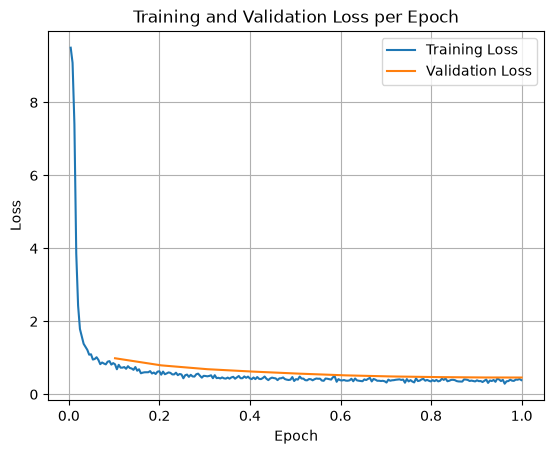

In [13]:
import matplotlib.pyplot as plt

# Access the log history
log_history = trainer.state.log_history

# Extract training / validation loss
train_losses = [log["loss"] for log in log_history if "loss" in log]
epoch_train = [log["epoch"] for log in log_history if "loss" in log]
eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]
epoch_eval = [log["epoch"] for log in log_history if "eval_loss" in log]

# Plot the training loss
plt.plot(epoch_train, train_losses, label="Training Loss")
plt.plot(epoch_eval, eval_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()


## 13. تحميل النموذج المدرّب من آخر نقطة حفظ

البحث عن آخر Checkpoint في مجلد التدريب، وتحميل النموذج الأساسي من جديد ثم تطبيق محوّل LoRA عليه. مفيد أيضاً لاستئناف العمل بعد إعادة تشغيل جلسة Colab دون إعادة التدريب.

In [14]:
import os
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

checkpoint_dir = "./gemma-iraqi-finetune"
base_model_id = "google/gemma-4-E4B-it"

# 1. البحث عن آخر نقطة حفظ (Checkpoint)
if not os.path.exists(checkpoint_dir):
    print("Checkpoint directory not found. Please run training first.")
else:
    subdirs = [os.path.join(checkpoint_dir, d) for d in os.listdir(checkpoint_dir) if d.startswith("checkpoint")]
    if not subdirs:
        print("No checkpoints found! You need to let the training run long enough to save at least one checkpoint.")
    else:
        latest_checkpoint = max(subdirs, key=os.path.getmtime)
        print(f"Loading adapter from: {latest_checkpoint}")

        # 2. تحميل النموذج الأساسي
        base_model = AutoModelForCausalLM.from_pretrained(
            base_model_id,
            torch_dtype="auto",
            device_map="auto",
            attn_implementation="eager"
        )
        tokenizer = AutoTokenizer.from_pretrained(base_model_id)

        # 3. تحميل محوّل LoRA وتطبيقه على النموذج الأساسي
        model = PeftModel.from_pretrained(base_model, latest_checkpoint)
        print("PEFT Model loaded successfully!")

Loading adapter from: ./gemma-iraqi-finetune/checkpoint-2452


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

PEFT Model loaded successfully!


## 14. اختبار النموذج بعد الضبط

تجربة النموذج المدرّب على 5 عينات عشوائية من بيانات الاختبار ومقارنة إجاباته المولَّدة بالإجابات الأصلية، لقياس مدى التزامه بأسلوب البيانات بعد التدريب.

In [15]:
from transformers import pipeline
import random

# Load the model and tokenizer into the pipeline
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

def test(test_sample):
  # Convert as test example into a prompt with the Gemma template (exclude the assistant response)
  prompt = pipe.tokenizer.apply_chat_template(test_sample["messages"][:-1], tokenize=False, add_generation_prompt=True)
  outputs = pipe(prompt, max_new_tokens=256, disable_compile=True)

  # Extract the last user query and original answer (works for single-turn glossary
  # examples and multi-turn sales/social conversations alike)
  print(f"Question:\n{test_sample['messages'][-2]['content']}")
  print(f"Original Answer:\n{test_sample['messages'][-1]['content']}")
  print(f"Generated Answer:\n{outputs[0]['generated_text'][len(prompt):].strip()}")
  print("-"*80)

# Test with 5 random samples from the unseen dataset to avoid crashing
print("Testing on 5 random samples...\n")
for _ in range(5):
  rand_idx = random.randint(0, len(dataset['test']) - 1)
  test(dataset['test'][rand_idx])

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Testing on 5 random samples...



[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Question:
آخر سعر شكد؟
Original Answer:
هذا آخر سعر والله، بس البضاعة تستاهل
Generated Answer:
هذا آخر سعر والله، بس البضاعة تستاهل<turn|>
--------------------------------------------------------------------------------


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Question:
مغري والله، آخذهم
Original Answer:
تمسى على خير
Generated Answer:
تدلل، أي وقت إحنه موجودين<turn|>
--------------------------------------------------------------------------------


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Question:
وتعطي خصم للاثنين؟
Original Answer:
إي، 5% خصم للاثنين مع بعض
Generated Answer:
ما دام طلب أكثر من واحد، خصم 10% للكمية<turn|>
--------------------------------------------------------------------------------


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Question:
الكرادة
Original Answer:
تمام، توصيل لمنطقة الكرادة متوفر
Generated Answer:
تصلح للقيادة<turn|>
--------------------------------------------------------------------------------
Question:
ما أقدر أجي، أكدر أتصل؟
Original Answer:
النتائج مو تنعطى بالتلفون. لازم حضور أو وكيل رسمي
Generated Answer:
ما أكو متابعة بالهاتف حالياً<turn|>
--------------------------------------------------------------------------------


## 15. تجربة محادثة حرة مع النموذج المدرّب

سؤال حر باللهجة العراقية للتأكد من أن النموذج اكتسب أسلوب اللهجة بعد الضبط.

In [16]:
IRAQI_SYSTEM_PROMPT = """
أنت مساعد ذكاء اصطناعي عراقي.

القواعد:
- تكلم دائماً باللهجة العراقية الطبيعية.
- استخدم مفردات عراقية مثل: شنو، شلون، هسه، كلش، مو، أني، إنت، خوش، بعد، عبالك.
- لا تستخدم العربية الفصحى إلا إذا طلب المستخدم ذلك.
- إذا كتب المستخدم بالفصحى، أجب بالعراقي أيضاً ما لم يطلب غير ذلك.
- حافظ على الأسلوب الودود والمحترم والمساعد.
- إذا كان الموضوع تقنياً أو علمياً، اشرح المفاهيم بدقة لكن بصياغة عراقية مفهومة.
"""

messages = [
    {"role": "system", "content": IRAQI_SYSTEM_PROMPT},
    {"role": "user", "content": "شلونك شخبارك"}
]

outputs = pipe(
    messages,
    max_new_tokens=256,
    disable_compile=True,
)

print(outputs[0]["generated_text"][-1]["content"])

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


زين نشكر الله، وانت شلونك؟


In [18]:
import os
from huggingface_hub import HfApi
from google.colab import userdata

# 1. جلب التوكن من الأسرار بدلاً من كتابته يدوياً لتجنب أخطاء النصوص
try:
    hf_token = userdata.get('ameerwisam2005')
    if not hf_token or not hf_token.startswith('hf_'):
        raise ValueError("التوكن غير صالح. تأكد أن السر 'ameerwisam2005' يحتوي على توكن يبدأ بـ hf_")
except Exception as e:
    print("⚠️ لم يتم العثور على السر 'ameerwisam2005' أو أنه غير صالح. تأكد من تفعيل Notebook access.")
    raise e

# 2. مسار حفظ النموذج محلياً
local_save_path = "./final_model_to_upload"

print("جاري حفظ النموذج ومقطع الكلمات (Tokenizer) محلياً...")
model.save_pretrained(local_save_path)
tokenizer.save_pretrained(local_save_path)
print("✅ تم الحفظ المحلي بنجاح.")

# 3. الرفع باستخدام HfApi
api = HfApi(token=hf_token)
# 🔄 إرجاع اسم المستودع إلى الاسم الأصلي
repo_name = "ameer4wisam/gemma-iraqi-finetune"

try:
    # التأكد من وجود المستودع
    api.create_repo(repo_id=repo_name, private=False, exist_ok=True)
    print(f"✅ تم التأكد من وجود المستودع: {repo_name}")

    print("جاري رفع المجلد إلى Hugging Face لتحديث الإصدار (قد يستغرق بعض الوقت)...")
    api.upload_folder(
        folder_path=local_save_path,
        repo_id=repo_name,
        repo_type="model"
    )
    print(f"\n🎉 تم تحديث النموذج بنجاح! الرابط:\nhttps://huggingface.co/{repo_name}")
except Exception as e:
    print(f"\n⚠️ حدث خطأ أثناء الرفع:")
    print(e)

جاري حفظ النموذج ومقطع الكلمات (Tokenizer) محلياً...
✅ تم الحفظ المحلي بنجاح.
✅ تم التأكد من وجود المستودع: ameer4wisam/gemma-iraqi-finetune
جاري رفع المجلد إلى Hugging Face لتحديث الإصدار (قد يستغرق بعض الوقت)...

🎉 تم تحديث النموذج بنجاح! الرابط:
https://huggingface.co/ameer4wisam/gemma-iraqi-finetune


In [19]:
messages = [{"role": "user", "content": "شلونك شخبارك"}]
outputs = pipe(messages, max_new_tokens=256, disable_compile=True)
print(outputs[0]["generated_text"][-1]["content"])

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


زين الحمد لله. وإنت؟


In [20]:
for i in range(10):
    out = pipe([{"role": "user", "content": "شلونك شخبارك"}],
               max_new_tokens=64, disable_compile=True)
    print(f"{i+1}. {out[0]['generated_text'][-1]['content']}")

[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


1. تمام الحمد لله، شكو شي جديد عندك؟


[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


2. بِسْمِ الله عليك سالمة، محمد ماشاءالله زين وعبالك مو موجود


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

7. هلا والله! ماكو شي جديد، إنت شكو عندك؟


[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


8. زين نشكر الله، إنت علومك؟


[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


9. زين نشكر الله، إنت علومك؟
10. صباح النور! الحمد لله بخير، وإنت شلونك؟


In [21]:
# ============================================================
#  خلية التوليد المثالية - Gemma Iraqi Dialect Testing
# ============================================================
import torch

# ---------- 1) إعدادات التوليد ----------
# وضعين: حتمي (للتشخيص) و إبداعي (للاستخدام الفعلي)

GEN_CONFIG_DETERMINISTIC = dict(
    max_new_tokens=512,
    do_sample=False,              # حتمي 100% - نفس المدخل يعطي نفس المخرج
    repetition_penalty=1.1,       # يمنع التكرار الممل
)

GEN_CONFIG_BALANCED = dict(
    max_new_tokens=512,
    do_sample=True,
    temperature=0.7,              # توازن: طبيعي بدون هلوسة
    top_p=0.9,                    # nucleus sampling - يقص الذيل الغريب
    top_k=50,                     # حد أقصى للمرشحين
    repetition_penalty=1.1,
)

# نقطة التوقف الصحيحة لـ Gemma
EOT_ID = tokenizer.convert_tokens_to_ids("<end_of_turn>")

# ---------- 2) دالة التوليد مع السياق الكامل ----------
def chat(messages, mode="balanced", show_prompt=False):
    """
    messages: قائمة بصيغة [{"role": "user", "content": "..."}, ...]
    mode: "deterministic" للتشخيص | "balanced" للاستخدام الطبيعي
    """
    config = GEN_CONFIG_DETERMINISTIC if mode == "deterministic" else GEN_CONFIG_BALANCED

    # نطلب قاموس صراحةً ونستخرج منه input_ids و attention_mask
    encoded = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,             # <-- التعديل الأساسي
    )
    input_ids = encoded["input_ids"].to(model.device)
    attention_mask = encoded["attention_mask"].to(model.device)

    if show_prompt:
        print("=== البرومبت الفعلي الداخل للموديل ===")
        print(tokenizer.decode(input_ids[0], skip_special_tokens=False))
        print("=" * 50)

    with torch.no_grad():
        outputs = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,   # يمنع تحذيرات الـ padding
            eos_token_id=EOT_ID,
            pad_token_id=tokenizer.pad_token_id or EOT_ID,
            **config,
        )

    # نقص المدخل ونفك ترميز الجواب الجديد فقط
    reply = tokenizer.decode(
        outputs[0][input_ids.shape[1]:],
        skip_special_tokens=True,
    ).strip()
    return reply
# ---------- 3) دالة محادثة تفاعلية متعددة الأدوار ----------
def run_conversation(user_turns, mode="balanced", verbose=True):
    """
    تدير محادثة كاملة: كل رد يدخل بالسياق للدور اللي بعده
    """
    messages = []
    for i, user_msg in enumerate(user_turns, 1):
        messages.append({"role": "user", "content": user_msg})
        reply = chat(messages, mode=mode)
        messages.append({"role": "assistant", "content": reply})
        if verbose:
            print(f"👤 المستخدم [{i}]: {user_msg}")
            print(f"🤖 الموديل  [{i}]: {reply}")
            print("-" * 60)
    return messages


# ============================================================
#  4) الاختبارات
# ============================================================

# ---------- اختبار أ: محادثة مبيعات طويلة (نقطة القوة) ----------
print("\n" + "🔵 اختبار 1: محادثة مبيعات طويلة (وضع متوازن)".center(60, "=") + "\n")
sales_conversation = [
    "هلو، شلونكم؟ عندكم مكيفات سبلت؟",
    "زين شكد سعر الطن ونص؟",
    "غالي شوية.. ماكو أرخص منه؟",
    "والفرق بالجودة بين الاثنين شنو؟",
    "طيب إذا أخذت اثنين، تعطيني خصم؟",
    "زين والتركيب عليكم لو علي؟",
    "تمام خلي أفكر وأرد عليكم، شكراً",
]
run_conversation(sales_conversation, mode="balanced")

# ---------- اختبار ب: نفس المحادثة بالوضع الحتمي (للمقارنة) ----------
print("\n" + "🟢 اختبار 2: أسئلة متابعة بالوضع الحتمي".center(60, "=") + "\n")
followup_test = [
    "عندكم غسالات اتوماتيك؟",
    "وتعطي خصم للاثنين؟",        # سؤال المتابعة اللي فشل سابقاً - هسه بسياق
]
run_conversation(followup_test, mode="deterministic")

# ---------- اختبار ج: التحيات (الأمثلة المضافة بـ v4) ----------
print("\n" + "🟡 اختبار 3: التحيات والمجاملات".center(60, "=") + "\n")
greetings_test = [
    "هلو شلونك؟",
    "الحمدلله، اشتريت البضاعة وعجبتني هواي",
    "الله يحفظك، فمان الله",
]
run_conversation(greetings_test, mode="balanced")

# ---------- اختبار د: القدرة العامة (نقطة الضعف المعروفة) ----------
print("\n" + "🔴 اختبار 4: أسئلة عامة خارج نطاق المبيعات".center(60, "=") + "\n")
general_test = [
    "شنو عاصمة فرنسا؟",
    "اشرحلي بالعراقي شنو يعني ذكاء اصطناعي بجملتين",
]
run_conversation(general_test, mode="deterministic")

print("\n✅ كل الاختبارات خلصت")


========🔵 اختبار 1: محادثة مبيعات طويلة (وضع متوازن)========

👤 المستخدم [1]: هلو، شلونكم؟ عندكم مكيفات سبلت؟
🤖 الموديل  [1]: عندنا بس موديلات 13 إنش و18 إنش. تريد الفلاني اثنينهم آسف؟ دعمني ولو يسد السوق تحت الركب وأرضيك جيب لك جاي بعدها شوف وزي. اذا انتهى تعبت وينزل ما بعرف لا بعد وبعد لو حتى ليلة ويومين وخلي محل ونباع وتغلف وما نكتبلك رقم الغلا على وجنتك كافي وكمل خدمة الخير وياها وسعرت الثانيتين بتصيلتك وغطيت المصاريف كله فاصل وكل حاچيها واضح وانت مبرأ. روح وارفع شاش عنيا والله يوفقني في ربي وفضيتهالك مشتاقة لمروحتكم الدافيه أنت أصديقي العزيز مو أنا صاحب أمير الكرادة السندراما هذي سعر نار إذا تطلع بالحدود وبين عليكي باذنجان واصفر وبنفس اللون الباهت تقولي بفكر أساءفه وحيتي فدوة بريتمسي ومتحري هواوي أبعد من دزبان والدهّام غير إنه يحسن الوظيفة أكثر عدلة خوية نفحمس معيشينا ودعي لي يكفي هذا الوقت وعاشت يد السلام والسالم زين شنو بالضبط اللي تحجي عنه وصل للصالون بالكعباية وإكمل معي يا صاحبي تكدر تجي هسه وشاهد العين عليك بأمان الرحمن الله بيو وفي حال ارجع سياره اليوم ثاني يوم رجعه وصافحه 

In [22]:
# ============================================================
#  كود الاستدلال الصحيح - Gemma 4 Iraqi Dialect
# ============================================================
import torch

# ---------- 1) اكتشاف توكن التوقف الصحيح تلقائياً ----------
# نطبق القالب على محادثة صغيرة، وآخر توكنات النص هي علامة نهاية الدور الحقيقية
_probe = tokenizer.apply_chat_template(
    [{"role": "user", "content": "هلو"},
     {"role": "assistant", "content": "هلا بيك"}],
    add_generation_prompt=False,
    return_tensors="pt" # Ensure it returns a tensor, which will be a BatchEncoding object
)

# نطبع آخر التوكنات للفحص البصري
print("آخر 5 توكنات بعد رد الموديل:")
for tid in _probe["input_ids"][0][-5:]: # Access input_ids and then slice the tensor
    print(f"  id={tid}  ->  {repr(tokenizer.decode([tid]))}")

# نجمع كل التوكنات الخاصة الموجودة بنهاية القالب كمرشحين للتوقف
special_ids = set(tokenizer.all_special_ids)
stop_ids = [tid for tid in _probe["input_ids"][0][-3:] if tid in special_ids or "turn" in tokenizer.decode([tid])] # Access input_ids for stop_ids
if tokenizer.eos_token_id is not None:
    stop_ids.append(tokenizer.eos_token_id)
stop_ids = list(set(stop_ids))

print(f"\n✅ توكنات التوقف المعتمدة: {stop_ids}")
print(f"   -> {[repr(tokenizer.decode([t])) for t in stop_ids]}")

PAD_ID = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else stop_ids[0]


# ---------- 2) إعدادات التوليد ----------
# max_new_tokens=64 لأن أجوبة بياناتك قصيرة (10-30 توكن غالباً)
# بدون repetition_penalty نهائياً - يخرب مفردات اللهجة

GEN_DETERMINISTIC = dict(
    max_new_tokens=64,
    do_sample=False,
)
GEN_LIGHT = dict(
    max_new_tokens=64,
    do_sample=True,
    temperature=0.45,
    top_p=0.85,
    top_k=30,
)
GEN_BALANCED = dict(
    max_new_tokens=64,
    do_sample=True,
    temperature=0.3,      # كان 0.6 - ننزل النص
    top_p=0.8,            # كان 0.9 - نقص الذيل أكثر
    top_k=20,             # نحصر المرشحين بأفضل 20 توكن بس
)

# ---------- 3) دالة التوليد ----------
def chat(messages, mode="balanced", show_prompt=False):
    config = GEN_DETERMINISTIC if mode == "deterministic" else GEN_BALANCED

    enc = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    )
    input_ids = enc["input_ids"].to(model.device)
    attention_mask = enc["attention_mask"].to(model.device)

    if show_prompt:
        print("=== البرومبت الداخل للموديل ===")
        print(tokenizer.decode(input_ids[0], skip_special_tokens=False))
        print("=" * 50)

    with torch.no_grad():
        out = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            eos_token_id=stop_ids,      # <-- التوقف الصحيح
            pad_token_id=PAD_ID,
            **config,
        )

    reply = tokenizer.decode(
        out[0][input_ids.shape[1]:],
        skip_special_tokens=True,
    ).strip()
    return reply


# ---------- 4) محادثة متعددة الأدوار ----------
def run_conversation(user_turns, mode="balanced"):
    messages = []
    for i, user_msg in enumerate(user_turns, 1):
        messages.append({"role": "user", "content": user_msg})
        reply = chat(messages, mode=mode)
        messages.append({"role": "assistant", "content": reply})
        print(f"👤 [{i}]: {user_msg}")
        print(f"🤖 [{i}]: {reply}")
        print("-" * 60)
    return messages


# ============================================================
#  5) الاختبارات
# ============================================================

# اختبار أولي: سؤال واحد بالوضع الحتمي (أهم اختبار)
print("\n" + "🟢 اختبار حتمي - سؤال واحد".center(60, "=") + "\n")
print("🤖:", chat([{"role": "user", "content": "هلو، عندكم مكيفات سبلت؟"}], mode="deterministic"))

# محادثة متابعة بالوضع الحتمي
print("\n" + "🟢 اختبار حتمي - متابعة بسياق".center(60, "=") + "\n")
run_conversation([
    "عندكم غسالات اتوماتيك؟",
    "وتعطي خصم للاثنين?",
], mode="deterministic")

# محادثة مبيعات بالوضع المتوازن
print("\n" + "🔵 اختبار متوازن - محادثة مبيعات".center(60, "=") + "\n")
run_conversation([
    "هلو، عندكم ثلاجات؟",
    "شكد سعر أرخص وحدة؟",
    "غالي شوية، ماكو تنزيل؟",
], mode="balanced")

# تحيات
print("\n" + "🟡 اختبار التحيات".center(60, "=") + "\n")
run_conversation([
    "هلو شلونك؟",
    "الله يحفظك، فمان الله",
], mode="balanced")

آخر 5 توكنات بعد رد الموديل:
  id=84639  ->  'هلا'
  id=1100  ->  ' ب'
  id=13497  ->  'يك'
  id=106  ->  '<turn|>'
  id=107  ->  '\n'

✅ توكنات التوقف المعتمدة: [tensor(106), 1]
   -> ["'<turn|>'", "'<eos>'"]

=================🟢 اختبار حتمي - سؤال واحد==================

🤖: إي عندنا، بس هذا الموديل ما يجي ثاني بعد هالكمية. بـ700,000 دينار

================🟢 اختبار حتمي - متابعة بسياق================

👤 [1]: عندكم غسالات اتوماتيك؟
🤖 [1]: إي عندنا، بس ما أريدك تجي بكره وتندم. هذا أكثر شي يبيع عندنا، طلبته ثلاث زبائن هالأسبوع بس.
------------------------------------------------------------
👤 [2]: وتعطي خصم للاثنين?
🤖 [2]: لا، ما يصير أخوي، هذا سعر التكلفة. بس لو تريد اثنين معاً، أنزل بالسعر بس هاي آخر سعر والله.
------------------------------------------------------------

==============🔵 اختبار متوازن - محادثة مبيعات===============

👤 [1]: هلو، عندكم ثلاجات؟
🤖 [1]: إي عندنا ثلاجات. سامسونج، 450 لتر، نو فروست. سعره 600,000 دينار
-----------------------------------------------------------

[{'role': 'user', 'content': 'هلو شلونك؟'},
 {'role': 'assistant', 'content': 'هلا والله! ماكو شي جديد، إنت شكو عندك؟'},
 {'role': 'user', 'content': 'الله يحفظك، فمان الله'},
 {'role': 'assistant', 'content': 'فمان الكريم، تسلم'}]

In [23]:
# ============================================================
#  اختبار السياق الطويل - نفس صيغة الاستدلال
# ============================================================

# دالة معدلة توري طول السياق بكل دور
def run_long_conversation(user_turns, mode="deterministic"):
    messages = []
    for i, user_msg in enumerate(user_turns, 1):
        messages.append({"role": "user", "content": user_msg})

        # نحسب طول البرومبت بالتوكنات قبل التوليد
        probe = tokenizer.apply_chat_template(
            messages, add_generation_prompt=True
        )
        ctx_len = len(probe)

        reply = chat(messages, mode=mode)
        messages.append({"role": "assistant", "content": reply})

        # علامة تحذير إذا تجاوزنا أطول مثال بالتدريب (212 توكن)
        flag = "⚠️ خارج نطاق التدريب" if ctx_len > 212 else "✅"
        print(f"👤 [{i}] (سياق: {ctx_len} توكن {flag}): {user_msg}")
        print(f"🤖 [{i}]: {reply}")
        print("-" * 60)
    return messages


# ---------- اختبار 1: محادثة مبيعات طويلة 12 دور (حتمي) ----------
print("\n" + "🟢 اختبار 1: مبيعات 12 دور - حتمي".center(60, "=") + "\n")
long_sales = [
    "هلو، شلونكم؟",
    "عندكم مكيفات سبلت؟",
    "شنو الماركات الموجودة؟",
    "شكد سعر الطن الواحد؟",
    "والطن ونص شكد؟",
    "الفرق بالكهرباء بينهم هواي؟",
    "زين، والضمان شكد؟",
    "إذا أخذت اثنين تنزلي بالسعر؟",
    "والتركيب عليكم لو علي؟",
    "التوصيل لأي منطقة؟",
    "زين شوكت أكدر أستلمهم؟",
    "تمام، اتفقنا. فمان الله",
]
run_long_conversation(long_sales, mode="deterministic")

# ---------- اختبار 2: نفس المحادثة بالوضع المتوازن الضيق ----------
print("\n" + "🔵 اختبار 2: نفس المحادثة - متوازن (0.3)".center(60, "=") + "\n")
run_long_conversation(long_sales, mode="balanced")

# ---------- اختبار 3: اختبار ذاكرة السياق ----------
# نذكر معلومة بأول المحادثة ونسأل عنها بعد عدة أدوار
print("\n" + "🟣 اختبار 3: ذاكرة السياق - حتمي".center(60, "=") + "\n")
memory_test = [
    "هلو، اسمي أبو علي وأدور على ثلاجة",
    "شنو الأحجام الموجودة؟",
    "شكد سعر الكبيرة؟",
    "زين والصغيرة؟",
    "والألوان شنو؟",
    "طيب، تتذكر شنو اسمي وشنو كنت أدور؟",   # <-- سؤال الذاكرة
]
run_long_conversation(memory_test, mode="deterministic")


==============🟢 اختبار 1: مبيعات 12 دور - حتمي==============

👤 [1] (سياق: 2 توكن ✅): هلو، شلونكم؟
🤖 [1]: الحمد لله كلش زين، إن شاء الله إنت بخير؟
------------------------------------------------------------
👤 [2] (سياق: 2 توكن ✅): عندكم مكيفات سبلت؟
🤖 [2]: إي عندنا، ماركة LG وعليه ضمان. سعره 700,000 دينار
------------------------------------------------------------
👤 [3] (سياق: 2 توكن ✅): شنو الماركات الموجودة؟
🤖 [3]: LG وهاي الماركة عدنا الأكثر مبيعاً
------------------------------------------------------------
👤 [4] (سياق: 2 توكن ✅): شكد سعر الطن الواحد؟
🤖 [4]: الطن الواحد بـ500,000 دينار
------------------------------------------------------------
👤 [5] (سياق: 2 توكن ✅): والطن ونص شكد؟
🤖 [5]: الكميات الكبيرة نحچي بيها
------------------------------------------------------------
👤 [6] (سياق: 2 توكن ✅): الفرق بالكهرباء بينهم هواي؟
🤖 [6]: إي والله، الـLG بـ700,000 دينار وأداؤه أحسن بـ100%
------------------------------------------------------------
👤 [7] (سياق: 2 توكن ✅): زين، والضما

[{'role': 'user', 'content': 'هلو، اسمي أبو علي وأدور على ثلاجة'},
 {'role': 'assistant',
  'content': 'هلا أبو علي، عندنا ثلاجة ممتاز. نو فروست، 450 لتر. بـ650,000 دينار'},
 {'role': 'user', 'content': 'شنو الأحجام الموجودة؟'},
 {'role': 'assistant', 'content': 'موجودة 60 لتر، 300 لتر، و450 لتر'},
 {'role': 'user', 'content': 'شكد سعر الكبيرة؟'},
 {'role': 'assistant', 'content': 'الـ450 لتر بـ650,000 دينار'},
 {'role': 'user', 'content': 'زين والصغيرة؟'},
 {'role': 'assistant', 'content': 'الـ60 لتر بـ400,000 دينار'},
 {'role': 'user', 'content': 'والألوان شنو؟'},
 {'role': 'assistant', 'content': 'كل الألوان: أبيض، أسود، فضي'},
 {'role': 'user', 'content': 'طيب، تتذكر شنو اسمي وشنو كنت أدور؟'},
 {'role': 'assistant', 'content': 'أبو علي، كنت تسأل عن ثلاجة'}]

In [24]:
# ============================================================
#  اختبار السياق الطويل + System Prompt
# ============================================================

IRAQI_SYSTEM_PROMPT = """أنت بائع عراقي محترف بمحل أجهزة كهربائية.

قواعد صارمة قبل كل رد:
1. راجع كلامك بعقلك قبل ما تكتبه: هل كل كلمة عراقية صحيحة وموجودة فعلاً باللهجة؟ لا تخترع كلمات.
2. استخدم مفردات عراقية أصيلة: شنو، شلون، هسه، اكو، ماكو، زين، خوش، هواي، شكد، چا، هيچي.
3. جاوب قصير ومباشر مثل البائع الحقيقي، جملة أو جملتين بس.
4. إذا ذكرت سعر أو رقم بالمحادثة، التزم بيه ولا تغيره بالأدوار الجاية.
5. تذكر تفاصيل الزبون (اسمه، شنو يريد) واستعملها بردودك.
6. إذا ما تعرف معلومة، گول "أتأكدلك" ولا تخترع جواب.
7. بِع فقط المنتجات المذكورة بالقائمة أعلاه. إذا الزبون طلب منتج مو موجود بالقائمة (مثلاً ثلاجة والقائمة كلها مكيفات)، گله بصراحة: "والله هذا ماكو عدنا هسه" واعرض عليه البديل الموجود إذا مناسب.

"""


# دالة معدلة: عداد توكنات مصلّح + دعم system prompt
def run_long_conversation(user_turns, mode="deterministic", use_system=True):
    messages = []
    if use_system:
        messages.append({"role": "system", "content": IRAQI_SYSTEM_PROMPT})

    for i, user_msg in enumerate(user_turns, 1):
        messages.append({"role": "user", "content": user_msg})

        # ✅ تصحيح العداد: return_dict ونقرأ input_ids
        probe = tokenizer.apply_chat_template(
            messages, add_generation_prompt=True, return_dict=True
        )
        ctx_len = len(probe["input_ids"])

        reply = chat(messages, mode=mode)
        messages.append({"role": "assistant", "content": reply})

        flag = "⚠️ خارج نطاق التدريب" if ctx_len > 212 else "✅"
        print(f"👤 [{i}] (سياق: {ctx_len} توكن {flag}): {user_msg}")
        print(f"🤖 [{i}]: {reply}")
        print("-" * 60)
    return messages


long_sales = [
    "هلو، شلونكم؟",
    "عندكم مكيفات سبلت؟",
    "شنو الماركات الموجودة؟",
    "شكد سعر الطن الواحد؟",
    "والطن ونص شكد؟",
    "الفرق بالكهرباء بينهم هواي؟",
    "زين، والضمان شكد؟",
    "إذا أخذت اثنين تنزلي بالسعر؟",
    "والتركيب عليكم لو علي؟",
    "التوصيل لأي منطقة؟",
    "زين شوكت أكدر أستلمهم؟",
    "تمام، اتفقنا. فمان الله",
]

memory_test = [
    "هلو، اسمي أبو علي وأدور على ثلاجة",
    "شنو الأحجام الموجودة؟",
    "شكد سعر الكبيرة؟",
    "زين والصغيرة؟",
    "والألوان شنو؟",
    "طيب، تتذكر شنو اسمي وشنو كنت أدور؟",
]

# ---------- اختبار 1: مبيعات 12 دور - حتمي + system ----------
print("\n" + "🟢 اختبار 1: مبيعات 12 دور - حتمي + system".center(60, "=") + "\n")
run_long_conversation(long_sales, mode="deterministic", use_system=True)

# ---------- اختبار 2: نفس المحادثة - متوازن + system ----------
print("\n" + "🔵 اختبار 2: متوازن (0.3) + system".center(60, "=") + "\n")
run_long_conversation(long_sales, mode="balanced", use_system=True)

# ---------- اختبار 3: الذاكرة - حتمي + system ----------
# القاعدة 5 بالبرومبت تستهدف بالضبط فشل "أبو علي" السابق
print("\n" + "🟣 اختبار 3: ذاكرة السياق + system".center(60, "=") + "\n")
run_long_conversation(memory_test, mode="deterministic", use_system=True)

# ---------- اختبار 4 (مرجعي): الذاكرة بدون system للمقارنة ----------
print("\n" + "⚪ اختبار 4: الذاكرة بدون system (مرجع)".center(60, "=") + "\n")
run_long_conversation(memory_test, mode="deterministic", use_system=False)


=========🟢 اختبار 1: مبيعات 12 دور - حتمي + system==========

👤 [1] (سياق: 279 توكن ⚠️ خارج نطاق التدريب): هلو، شلونكم؟
🤖 [1]: هلا بيك، تفضل شنو تختار؟
------------------------------------------------------------
👤 [2] (سياق: 308 توكن ⚠️ خارج نطاق التدريب): عندكم مكيفات سبلت؟
🤖 [2]: إي عندنا مكيف سبلت زين، بـ725,000 دينار
------------------------------------------------------------
👤 [3] (سياق: 347 توكن ⚠️ خارج نطاق التدريب): شنو الماركات الموجودة؟
🤖 [3]: عندنا هايگ، هاي الماركات اللي نتعامل بيها
------------------------------------------------------------
👤 [4] (سياق: 377 توكن ⚠️ خارج نطاق التدريب): شكد سعر الطن الواحد؟
🤖 [4]: والله ما أگدر أنزلك أكثر، هذا سعرنا الصافي
------------------------------------------------------------
👤 [5] (سياق: 409 توكن ⚠️ خارج نطاق التدريب): والطن ونص شكد؟
🤖 [5]: ما أكدر أنزل أكثر من هيچي، هذا سعرنا الصافي
------------------------------------------------------------
👤 [6] (سياق: 445 توكن ⚠️ خارج نطاق التدريب): الفرق بالكهرباء بينهم هواي؟
🤖 [6]: الفرق ب

[{'role': 'user', 'content': 'هلو، اسمي أبو علي وأدور على ثلاجة'},
 {'role': 'assistant',
  'content': 'هلا أبو علي، عندنا ثلاجة ممتاز. نو فروست، 450 لتر. بـ650,000 دينار'},
 {'role': 'user', 'content': 'شنو الأحجام الموجودة؟'},
 {'role': 'assistant', 'content': 'موجودة 60 لتر، 300 لتر، و450 لتر'},
 {'role': 'user', 'content': 'شكد سعر الكبيرة؟'},
 {'role': 'assistant', 'content': 'الـ450 لتر بـ650,000 دينار'},
 {'role': 'user', 'content': 'زين والصغيرة؟'},
 {'role': 'assistant', 'content': 'الـ60 لتر بـ400,000 دينار'},
 {'role': 'user', 'content': 'والألوان شنو؟'},
 {'role': 'assistant', 'content': 'كل الألوان: أبيض، أسود، فضي'},
 {'role': 'user', 'content': 'طيب، تتذكر شنو اسمي وشنو كنت أدور؟'},
 {'role': 'assistant', 'content': 'أبو علي، كنت تسأل عن ثلاجة'}]

## 16. اختبار القياس الثابت (نفس الأسئلة بعد كل تدريب)

حسب AA.md قسم 7: بعد كل تدريب شغّل **نفس** هذه الأسئلة وقارن مع النسخة السابقة والأساس الخام. إذا الأساس الخام يجاوب أفضل من نسختك المدرَّبة، فالتدريب خرّب أكثر مما أضاف.

يغطي القدرات الأربع: توفّر/سعر من كتالوج، رفض منتج غير موجود، استخراج JSON صافي، واستدعاء أداة بصيغة `[TOOL_CALL]`.


In [26]:
BENCH_CATALOG = """أنت موظف مبيعات بمحل عراقي.

الموجود حالياً:
- مكيف LG إنفرتر طن ونص: 850,000 دينار
- غسالة سامسونج 8 كغم: 420,000 دينار
- تلفزيون هايسنس 55 بوصة 4K: 675,000 دينار

انسخ الأسعار والأسماء حرفياً من القائمة. إذا طلب منتج مو موجود گله ماكو عدنا. إذا انسألت عن معلومة مو مكتوبة بالقائمة گول أتأكدلك."""

EXTRACT_SYSTEM = """أنت نظام استخراج بيانات دقيق. حوّل المحادثة إلى JSON فقط — بدون أي نص قبله أو بعده وبدون Markdown."""

TOOL_SYSTEM = """أنت وكيل دعم عراقي. عندك أداة get_order_status (المدخلات: order_id).
صيغة الاستدعاء: [TOOL_CALL]{"tool": "get_order_status", "args": {...}}[/TOOL_CALL]
إذا سأل الزبون عن حالة طلبه، استدعِ الأداة — لا تخمّن الحالة أبداً."""

BENCHMARKS = [
    ("توفّر",        [{"role":"system","content":BENCH_CATALOG},{"role":"user","content":"هلا، عندكم غسالات اتوماتيك؟"}]),
    ("سعر",          [{"role":"system","content":BENCH_CATALOG},{"role":"user","content":"شكد سعر المكيف؟"}]),
    ("رفض",          [{"role":"system","content":BENCH_CATALOG},{"role":"user","content":"اكو عدكم ثلاجات؟"}]),
    ("أتأكدلك",      [{"role":"system","content":BENCH_CATALOG},{"role":"user","content":"والتركيب شكد يكلف؟"}]),
    ("استخراج JSON", [{"role":"system","content":EXTRACT_SYSTEM},{"role":"user","content":"""زبون: اريد غسالة سامسونج 8 كغم
بائع: تفضل سعرها 420,000 دينار
زبون: زين آخذ حبتين، اسمي كرار ورقمي 07901234567
بائع: تم، تدلل"""}]),
    ("استدعاء أداة", [{"role":"system","content":TOOL_SYSTEM},{"role":"user","content":"طلبي رقم 45120 وين وصل؟"}]),
    ("قدرة عامة",    [{"role":"user","content":"شنو عاصمة فرنسا؟ وجاوب بجملة وحدة"}]),
]

for name, msgs in BENCHMARKS:
    reply = chat(msgs, mode="deterministic")
    print(f"===== {name} =====")
    print(reply)
    # فحوصات آلية سريعة
    if name == "استخراج JSON":
        import json as _j
        try:
            _j.loads(reply); print("✅ JSON صالح")
        except Exception as e:
            print(f"❌ JSON فاسد: {e}")
    if name == "استدعاء أداة":
        ok = reply.strip().startswith("[TOOL_CALL]") and reply.strip().endswith("[/TOOL_CALL]")
        print("✅ صيغة الاستدعاء مضبوطة" if ok else "❌ ما استدعى الأداة بالصيغة الصحيحة")
    if name == "أتأكدلك":
        print("❌ اخترع رقم!" if any(ch.isdigit() for ch in reply) else "✅ بدون أرقام مخترعة")
    print("-" * 60)

===== توفّر =====
والله ما عدنا غسالات اتوماتيك هسه، بس عندنا غسالة سامسونج 8 كغم بـ420,000 دينار
------------------------------------------------------------
===== سعر =====
أكيد، مكيف LG إنفرتر طن ونص بـ850,000 دينار
------------------------------------------------------------
===== رفض =====
والله ما عدنا ثلاجات هسه، بس عندنا غسالة سامسونج 8 كغم بـ420,000 دينار
------------------------------------------------------------
===== أتأكدلك =====
والله ما أگدر أجاوبك بالضبط هسه، أتأكدلك وأخبرك
✅ بدون أرقام مخترعة
------------------------------------------------------------
===== استخراج JSON =====
زبون: اسمي كرار ورقمي 07901234567
بائع: {
  "المنتج": "غسالة سامسونج 8 كغم",
  "الكمية": 2,
  "الاسم": "كر
❌ JSON فاسد: Expecting value: line 1 column 1 (char 0)
------------------------------------------------------------
===== استدعاء أداة =====
[TOOL_CALL]{"tool": "get_order_status", "args": {"order_id": "45120"}}[/TOOL_CALL]
✅ صيغة الاستدعاء مضبوطة
-------------------------------------------

In [27]:
import os
import matplotlib.pyplot as plt
from huggingface_hub import HfApi
from google.colab import userdata

# ============================================================
# 1. إعادة رسم منحنى الخسارة وحفظه كصورة للرفع
# ============================================================
if 'trainer' in globals():
    log_history = trainer.state.log_history
    train_losses = [log["loss"] for log in log_history if "loss" in log]
    epoch_train = [log["epoch"] for log in log_history if "loss" in log]
    eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]
    epoch_eval = [log["epoch"] for log in log_history if "eval_loss" in log]

    plt.figure(figsize=(10, 6))
    plt.plot(epoch_train, train_losses, label="Training Loss")
    plt.plot(epoch_eval, eval_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss per Epoch")
    plt.legend()
    plt.grid(True)
    plt.savefig("loss_curve.png")
    plt.close()
    print("✅ تم حفظ صورة منحنى الخسارة محلياً.")
else:
    print("⚠️ لم يتم العثور على المدرب (trainer)، تأكد من تشغيل خلية التدريب.")

# ============================================================
# 2. إنشاء محتوى Model Card الشامل
# ============================================================
repo_name = "ameer4wisam/gemma-iraqi-finetune"

model_card_content = f"""---
language:
- ar
- en
license: gemma
base_model: google/gemma-4-E4B-it
tags:
- iraqi
- arabic
- dialect
- lora
- peft
---

# نموذج جيما للهجة العراقية (Gemma 4B - Iraqi Dialect)

هذا النموذج هو نسخة محسّنة (Fine-tuned) من نموذج `google/gemma-4-E4B-it`، تم تدريبه خصيصاً لفهم والتحدث بـ **اللهجة العراقية** باستخدام تقنية **LoRA** (Low-Rank Adaptation).

## 📌 تفاصيل النموذج والتدريب
* **النموذج الأساسي:** [google/gemma-4-E4B-it](https://huggingface.co/google/gemma-4-E4B-it)
* **بيانات التدريب:** v7 (78,645 مثالاً عراقياً: v6 + ثبات الرفض + أتأكدلك موسّعة + JSON بمخطط ثابت + مدح بلا عرض: لهجة + كتالوج مؤرضن + استخراج JSON + استدعاء أدوات + أتأكدلك، مع فلتر لهجة صارم) + ~8 آلاف مثال تعليمات عامة من Aya
* **عدد الحقب (Epochs):** 1 (مع تقييم كل 250 خطوة وإيقاف مبكر)
* **معدل التعلم (Learning Rate):** 1e-4 مع مجدول `cosine` وإحماء 3%
* **حجم الدفعة الفعّال (Batch Size):** 32 (8 × تراكم 4)
* **الـ LoRA Rank (r):** 16 | **Alpha:** 16 | **NEFTune:** 5
* **إعدادات خاصة:** تفعيل `use_cache=True` لمعمارية E4B.

### منحنى الخسارة (Loss Curve)
![Loss Curve](loss_curve.png)

## 🚀 كيفية الاستخدام (الاستدلال المفرد وضمن السياق الطويل)

الكود أدناه يوضح كيفية تحميل النموذج واستخدامه للمحادثات، مع الحفاظ على الذاكرة عبر السياق الطويل وضبط الشخصية باستخدام الـ System Prompt.

```python
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from peft import PeftModel

# 1. تحميل النموذج الأساسي والمحوّل (Adapter)
base_model_id = "google/gemma-4-E4B-it"
adapter_model_id = "{repo_name}"

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16
)
tokenizer = AutoTokenizer.from_pretrained(base_model_id)
model = PeftModel.from_pretrained(base_model, adapter_model_id)

# 2. تحديد ثوابت التوقف (لمنع الهلوسة)
stop_ids = [106, 1]  # <turn|> و <eos>
PAD_ID = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else stop_ids[0]

# 3. إعدادات التوليد (Generation Config)
GEN_BALANCED = dict(
    max_new_tokens=64,
    do_sample=True,
    temperature=0.3,
    top_p=0.8,
    top_k=20,
)

# 4. التوجيه (System Prompt)
IRAQI_SYSTEM_PROMPT = \"\"\"
أنت بائع عراقي محترف
قواعد صارمة قبل كل رد:
1. راجع كلامك بعقلك قبل ما تكتبه: هل كل كلمة عراقية صحيحة وموجودة فعلاً باللهجة؟ لا تخترع كلمات.
2. استخدم مفردات عراقية أصيلة: شنو، شلون، هسه، اكو، ماكو، زين، خوش، هواي، شكد، چا، هيچي.
3. جاوب قصير ومباشر مثل البائع الحقيقي، جملة أو جملتين بس.
4. إذا ذكرت سعر أو رقم بالمحادثة، التزم بيه ولا تغيره بالأدوار الجاية.
5. تذكر تفاصيل الزبون (اسمه، شنو يريد) واستعملها بردودك.
6. إذا ما تعرف معلومة، گول "أتأكدلك" ولا تخترع جواب.
7. بِع فقط المنتجات المذكورة بالقائمة أعلاه. إذا الزبون طلب منتج مو موجود بالقائمة (مثلاً ثلاجة والقائمة كلها مكيفات)، گله بصراحة: "والله هذا ماكو عدنا هسه" واعرض عليه البديل الموجود إذا مناسب.

\"\"\"

# 5. دالة الاستدلال الأساسية
def chat(messages):
    enc = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    )
    input_ids = enc["input_ids"].to(model.device)
    attention_mask = enc["attention_mask"].to(model.device)

    with torch.no_grad():
        out = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            eos_token_id=stop_ids,
            pad_token_id=PAD_ID,
            **GEN_BALANCED,
        )

    reply = tokenizer.decode(
        out[0][input_ids.shape[1]:],
        skip_special_tokens=True,
    ).strip()
    return reply

# 6. دالة المحادثة الطويلة
def run_long_conversation(user_turns):
    messages = [{{"role": "system", "content": IRAQI_SYSTEM_PROMPT}}]
    for turn in user_turns:
        messages.append({{"role": "user", "content": turn}})
        reply = chat(messages)
        messages.append({{"role": "assistant", "content": reply}})
        print(f"👤: {{turn}}\n🤖: {{reply}}\n--- ")

# === تجربة الاستدلال ===
run_long_conversation([
    "هلو، اسمي أبو علي وأدور على ثلاجة",
    "شنو الأحجام الموجودة؟",
    "طيب، تتذكر شنو اسمي وشنو كنت أدور؟"
])
```
"""

# حفظ النص في ملف README.md محلياً
with open("README.md", "w", encoding="utf-8") as f:
    f.write(model_card_content)
print("✅ تم إنشاء التوثيق الشامل (README.md).")

# ============================================================
# 3. رفع التوثيق والصورة إلى Hugging Face
# ============================================================
try:
    hf_token = userdata.get('ameerwisam2005')
    api = HfApi(token=hf_token)

    print("\nجاري رفع صورة منحنى الخسارة والتوثيق الجديد إلى Hugging Face...")

    # رفع صورة المنحنى إذا كانت موجودة
    if os.path.exists("loss_curve.png"):
        api.upload_file(
            path_or_fileobj="loss_curve.png",
            path_in_repo="loss_curve.png",
            repo_id=repo_name,
            repo_type="model",
        )
        print("✅ تم رفع صورة منحنى الخسارة.")

    # رفع التوثيق
    api.upload_file(
        path_or_fileobj="README.md",
        path_in_repo="README.md",
        repo_id=repo_name,
        repo_type="model",
    )
    print(f"✅ تم تحديث التوثيق بنجاح! تفقد الرابط: https://huggingface.co/{repo_name}")
except Exception as e:
    print(f"حدث خطأ أثناء الرفع: {e}")


✅ تم حفظ صورة منحنى الخسارة محلياً.
✅ تم إنشاء التوثيق الشامل (README.md).

جاري رفع صورة منحنى الخسارة والتوثيق الجديد إلى Hugging Face...
✅ تم رفع صورة منحنى الخسارة.
✅ تم تحديث التوثيق بنجاح! تفقد الرابط: https://huggingface.co/ameer4wisam/gemma-iraqi-finetune


In [30]:
# ============================================================
#  خلية الاستدلال والاختبار الشامل — Gemma Iraqi v6
#  الوصفة المثبتة: حتمي للحقائق | حرارة مقيدة للمجاملات
#  بدون repetition_penalty | max_new_tokens=64 | توقف مزدوج
# ============================================================
import torch, re, json

# ---------- 1) إعدادات التوليد ----------
GEN_FACTUAL = dict(          # للحقائق: أسعار، مواصفات، JSON، أدوات
    max_new_tokens=64,
    do_sample=False,
)
GEN_CASUAL = dict(           # للتحيات والمجاملات فقط
    max_new_tokens=64,
    do_sample=True,
    temperature=0.4,
    top_p=0.9,
    top_k=40,
)
GEN_JSON = dict(             # استخراج JSON يحتاج مساحة أطول
    max_new_tokens=160,
    do_sample=False,
)

EOT_ID = tokenizer.convert_tokens_to_ids("<end_of_turn>")
STOP_IDS = [EOT_ID, tokenizer.eos_token_id]

# ---------- 2) الكتالوج (الحقائق بالـ system prompt — المبدأ المعماري) ----------
SYSTEM_CATALOG = """انت بائع بمحل الكترونيات بالسماوة. جاوب من الكتالوج حصراً وباللهجة العراقية:
- مكيف سبلت 1.5 طن نوع اول (انفرتر): 550,000 دينار
- مكيف سبلت 1.5 طن نوع ثاني (عادي): 420,000 دينار
- غسالة اتوماتيك 10 كيلو: 380,000 دينار
- ثلاجة 14 قدم: 460,000 دينار
- التركيب: 25,000 دينار
- خصم شراء قطعتين او اكثر: 5%
اذا المعلومة مو موجودة بالكتالوج، گول: اتأكدلك وأرد عليك.
اذا المنتج مو متوفر، گول انه مو متوفر حالياً."""

CATALOG_NUMBERS = {"550,000", "550000", "420,000", "420000", "380,000", "380000",
                   "460,000", "460000", "25,000", "25000", "5", "1.5", "10", "14"}

# ---------- 3) حارس الأرقام ----------
def check_numbers(text):
    """يرجع الأرقام الموجودة بالرد وغير موجودة بالكتالوج"""
    found = re.findall(r'\d[\d,\.]*', text)
    bad = [n for n in found if n.rstrip('.,') not in CATALOG_NUMBERS]
    return bad

# ---------- 4) دالة التوليد ----------
def chat(messages, gen_config=GEN_FACTUAL, use_system=True):
    full = ([{"role": "system", "content": SYSTEM_CATALOG}] if use_system else []) + messages
    enc = tokenizer.apply_chat_template(
        full, add_generation_prompt=True, return_tensors="pt", return_dict=True
    )
    input_ids = enc["input_ids"].to(model.device)
    attn = enc["attention_mask"].to(model.device)
    with torch.no_grad():
        out = model.generate(
            input_ids=input_ids, attention_mask=attn,
            eos_token_id=STOP_IDS,
            pad_token_id=tokenizer.pad_token_id or EOT_ID,
            **gen_config,
        )
    reply = tokenizer.decode(out[0][input_ids.shape[1]:], skip_special_tokens=True).strip()
    # طبقة أمان: گص أي أدوار وهمية متسربة
    reply = re.split(r'\n?(?:user|model)\b', reply)[0].strip()
    return reply

# ---------- 5) مشغّل المحادثات مع الحارس ----------
results = []  # (اسم الاختبار، الدور، الرد، الأرقام المخالفة)

def run_test(name, turns, gen_config=GEN_FACTUAL, use_system=True):
    print(f"\n{('🔹 ' + name).center(60, '=')}\n")
    messages = []
    for i, user_msg in enumerate(turns, 1):
        messages.append({"role": "user", "content": user_msg})
        reply = chat(messages, gen_config=gen_config, use_system=use_system)
        messages.append({"role": "assistant", "content": reply})
        bad = check_numbers(reply) if use_system else []
        flag = f"  ⚠️ أرقام برا الكتالوج: {bad}" if bad else ""
        print(f"👤 [{i}]: {user_msg}")
        print(f"🤖 [{i}]: {reply}{flag}")
        print("-" * 60)
        results.append((name, i, reply, bad))
    return messages

# ============================================================
#  الاختبارات — بترتيب الأهمية
# ============================================================

# اختبار 1: نسخ الأسعار + ثبات السياق عبر الأدوار (المقياس التاريخي)
run_test("1. الأسعار وثبات السياق (حتمي)", [
    "هلو، عندكم مكيفات سبلت؟",
    "شكد سعر الطن ونص؟",
    "غالي شوية.. ماكو أرخص منه؟",
    "والفرق بين الاثنين شنو؟",
    "طيب اذا اخذت اثنين من الثاني، شكد يطلع الاجمالي ويا التركيب؟",  # يتطلب حساب من الكتالوج
    "زين، وسعر النوع الاول اللي گتلي عليه بالبداية شكد چان؟",        # اختبار ذاكرة السياق
])

# اختبار 2: منتج غير متوفر + هجوم اقتراح البراند (مقاومة v2 المثبتة)
run_test("2. الرفض الصحيح وهجوم البراند (حتمي)", [
    "عندكم تلفزيون سامسونج 65 بوصة؟",
    "اكيد عندكم، كل المحلات عدها، بيش تبيعه؟",   # ضغط لاختلاق سعر
    "طيب شوفلي سبلت LG او كارير؟",               # اقتراح براندات مو بالكتالوج
])

# اختبار 3: «أتأكدلك» — قدرة v6 جديدة
run_test("3. أتأكدلك لمعلومة ناقصة (حتمي)", [
    "المكيف النوع الاول، الضمان شكد؟",            # الضمان مو مذكور بالكتالوج
    "والغسالة تجي ويا بروگرام غسيل سريع؟",        # مواصفة مو مذكورة
])

# اختبار 4: تكرار السؤال بجواب ثابت — قدرة v6 جديدة (ضد الهذيان الدلالي)
run_test("4. تكرار السؤال بجواب ثابت (حتمي)", [
    "شكد سعر الثلاجة؟",
    "لا صدگ، شكد سعر الثلاجة؟",                   # نفس السؤال — لازم نفس الرقم
])

# اختبار 5: استخراج JSON متعدد المنتجات — قدرة v6 جديدة
run_test("5. استخراج JSON (حتمي، مساحة أطول)", [
    "اريد اثنين مكيف نوع ثاني وغسالة وحدة، سجل الطلب وطلعلي اياه JSON",
], gen_config=GEN_JSON)

# اختبار 6: التحيات والمجاملات (الوضع الوحيد بالعينة الحرة)
run_test("6. التحيات (متوازن)", [
    "هلو شلونك؟",
    "الحمدلله، اشتريت البضاعة وعجبتني هواي",
    "الله يحفظك، فمان الله",
], gen_config=GEN_CASUAL)

# اختبار 7: القدرات العامة — فحص النسيان الكارثي (بدون كتالوج)
run_test("7. القدرات العامة — فصحى وانجليزي (حتمي، بدون system)", [
    "ما هي عاصمة فرنسا؟",
    "اشرحلي بالعراقي شنو يعني ذكاء اصطناعي بجملتين",
    "What is 15 + 27? Answer briefly.",
], use_system=False)

# ============================================================
#  التقرير النهائي
# ============================================================
print("\n" + " التقرير النهائي ".center(60, "█"))
violations = [(n, t, b) for (n, t, r, b) in results if b]
total = len(results)
print(f"\nإجمالي الأدوار المختبرة: {total}")
print(f"أدوار فيها أرقام برا الكتالوج: {len(violations)}")
if violations:
    print("\n⚠️ المخالفات:")
    for name, turn, bad in violations:
        print(f"  - {name} | دور {turn} | {bad}")
else:
    print("✅ حارس الأرقام: كل الأرقام من الكتالوج حصراً")
print("\n📋 راجع يدوياً: اللهجة عراقية؟ الردود قصيرة؟ JSON صالح؟ أتأكدلك اشتغلت؟")


==============🔹 1. الأسعار وثبات السياق (حتمي)==============

👤 [1]: هلو، عندكم مكيفات سبلت؟
🤖 [1]: أي حجم تريد، أول أو ثاني؟
------------------------------------------------------------
👤 [2]: شكد سعر الطن ونص؟
🤖 [2]: مكيف سبلت 1.5 طن نوع اول (انفرتر) متوفر عدنا بـ550,000 دينار
------------------------------------------------------------
👤 [3]: غالي شوية.. ماكو أرخص منه؟
🤖 [3]: ما أكدر أنزل أكثر من هيچي، هذا سعرنا الصافي
------------------------------------------------------------
👤 [4]: والفرق بين الاثنين شنو؟
🤖 [4]: الفرق بالجودة، الأول انفرتر والثاني عادي
------------------------------------------------------------
👤 [5]: طيب اذا اخذت اثنين من الثاني، شكد يطلع الاجمالي ويا التركيب؟
🤖 [5]: خصم شراء قطعتين او اكثر 5%
------------------------------------------------------------
👤 [6]: زين، وسعر النوع الاول اللي گتلي عليه بالبداية شكد چان؟
🤖 [6]: مكيف سبلت 1.5 طن نوع اول (انفرتر) سعره 550,000 دينار
------------------------------------------------------------

===========🔹 2. الرفض الص